<hr>
<h1 style="text-align: center;">Source Panel Method</h1>
<hr>

<h3 style="text-align: center;">Ephraim Aung</h3>
<h3 style="text-align: center;">Student ID: 920074048</h3>
<h3 style="text-align: center;">Project #: 4</h3>
<h3 style="text-align: center;">Date:11/22/2024 </h3>

<h3 style="text-align: center;">EAE 127: Applied Aerodynamics</h3>
<h3 style="text-align: center;">University of California, Davis</h3>

<hr>

Setup

In [189]:
import math
import pyxfoil
import numpy as np
import matplotlib.pyplot as plt

from scipy import integrate


#STANDARD IMPORTS
import os
### JUPYTER NOTEBOOK SETTINGS ########################################
#Plot all figures in full-size cells, no scroll bars
%matplotlib inline
#Disable Python Warning Output
#(NOTE: Only for production, comment out for debugging)
import warnings
warnings.filterwarnings('ignore')
### PLOTTING DEFAULTS BOILERPLATE (OPTIONAL) #########################
#SET DEFAULT FIGURE APPERANCE
import seaborn as sns #Fancy plotting package
#No Background fill, legend font scale, frame on legend
sns.set(style='whitegrid', font_scale=1.5, rc={'legend.frameon': True})
#Mark ticks with border on all four sides (overrides 'whitegrid')
sns.set_style('ticks')
#ticks point in
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#fix invisible marker bug
sns.set_context(rc={'lines.markeredgewidth': 0.1})
#restore default matplotlib colormap
mplcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(mplcolors)

#Get color cycle for manual colors
colors = sns.color_palette()
#SET MATPLOTLIB DEFAULTS
#(call after seaborn, which changes some defaults)
params = {
#FONT SIZES
'axes.labelsize' : 30, #Axis Labels
'axes.titlesize' : 30, #Title
'font.size' : 28, #Textbox
'xtick.labelsize': 22, #Axis tick labels
'ytick.labelsize': 22, #Axis tick labels
'legend.fontsize': 24, #Legend font size
'font.family' : 'serif',
'font.fantasy' : 'xkcd',
'font.sans-serif': 'Helvetica',
'font.monospace' : 'Courier',
#AXIS PROPERTIES
'axes.titlepad' : 2*6.0, #title spacing from axis
'axes.grid' : True, #grid on plot
'figure.figsize' : (8,8), #square plots
'savefig.bbox' : 'tight', #reduce whitespace in saved figures
#LEGEND PROPERTIES
'legend.framealpha' : 0.5,
'legend.fancybox' : True,
'legend.frameon' : True,
'legend.numpoints' : 1,
'legend.scatterpoints' : 1,
'legend.borderpad' : 0.1,
'legend.borderaxespad' : 0.1,
'legend.handletextpad' : 0.2,
'legend.handlelength' : 1.0,
'legend.labelspacing' : 0,
}
import matplotlib
matplotlib.rcParams.update(params) #update matplotlib defaults, call after￿
### END OF BOILERPLATE ##################################################
colors = sns.color_palette() #color cycle

In [190]:
import numpy as np
import matplotlib.pyplot as plt

N = 250                                         # Number of points/sections to use in each direction for our flow
x_start, x_end = -5.0, 5.0                      # Boundaries of our flow in the x direction 
y_start, y_end = -1.5, 1.5                      # Boundaries of our flow in the y direction 

# Note, you can adjust the start and end points later to get the best image of your plot / flow

x = np.linspace(x_start, x_end, N)              # 1D array of x points
y = np.linspace(y_start, y_end, N)              # 1D array of y points
X, Y = np.meshgrid(x, y)                        # 2D Meshgrid 

1.0 Vortex Potential Flow

In [191]:


def get_vortex_velocity(Gamma, xv, yv, X, Y):

    # Here, input the equation for u_vortex from the equations above
    u = + Gamma / (2 * np.pi) * (Y - yv) / ((X - xv)**2 + (Y - yv)**2)

    # Here, input the equation for v_vortex from the equations above
    v = - Gamma / (2 * np.pi) * (X - xv) / ((X - xv)**2 + (Y - yv)**2)
    
    return u, v
def get_stream_function(strength, xs, ys, X, Y):
   
    # Here, input the equation for psi from the equations above
    psi = strength / (2 * np.pi) * np.arctan2((Y - ys), (X - xs))
    
    return psi



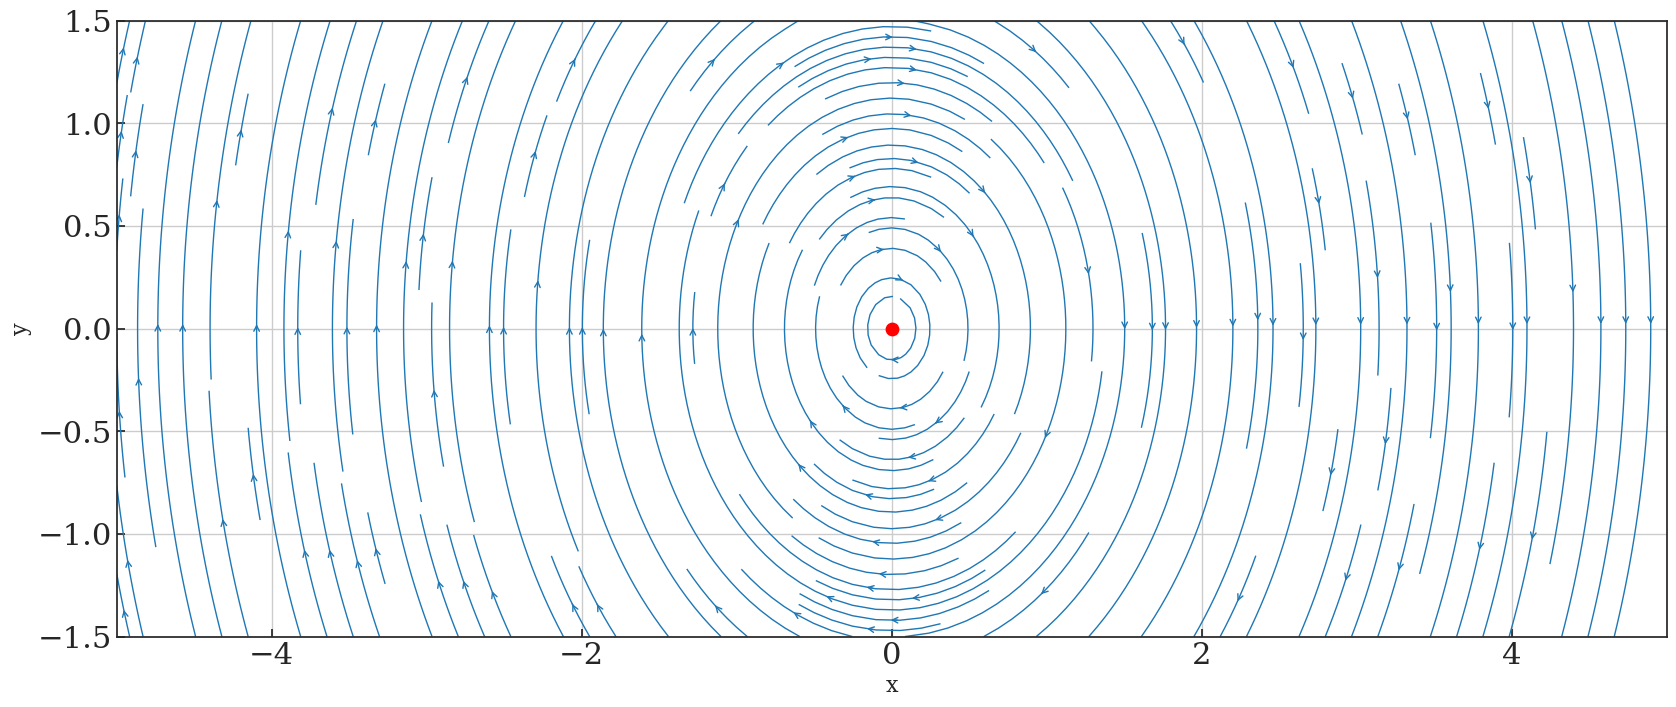

In [192]:
Gamma =  5                      # Strength of vortex singularity
x_vortex =  0.0                             # X coordinate of vortex singularity
y_vortex =  0.0                             # Y coordinate of vortex singularity        


u_vortex, v_vortex = get_vortex_velocity(Gamma, x_vortex, y_vortex, X, Y)
psi_source = get_stream_function(Gamma, x_vortex, y_vortex, X, Y)


width = 20
height = 8
plt.figure(figsize=(width, height))
plt.grid(True)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)

plt.streamplot(X, Y, u_vortex, v_vortex, density=2, linewidth=1, arrowsize=1, arrowstyle='->')

plt.scatter(x_vortex, y_vortex, color = 'red', s = 80, marker ='o')
plt.show()

In [193]:

def get_sum_locations(xv, yv, X, Y):
   
    # Here, input the equation for u_vortex from the equations above
    sumU = (Y-yv)/ ((X-xv)**2 + (Y-yv)**2)

    # Here, input the equation for v_vortex from the equations above
    sumV = (X-xv)/ ((X-xv)**2 + (Y-yv)**2)
    
    return sumU, sumV

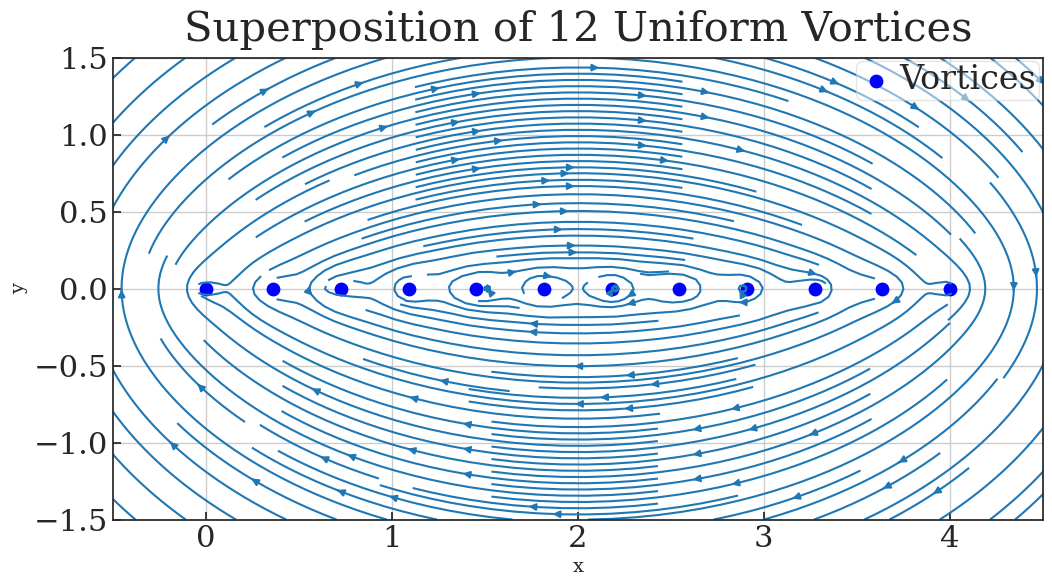

In [194]:

x_start, x_end = -2, 8
y_start, y_end = -1.5, 1.5
x_points, y_points = 100, 100
X, Y = np.meshgrid(
    np.linspace(x_start, x_end, x_points), 
    np.linspace(y_start, y_end, y_points)
)

# Number of vortices
num_vortices = 12
vortex_strength = Gamma  # Uniform vortex strength (same for all vortices)

# Generate linearly spaced x-coordinates for vortices
def generate_linear_x_loc(num_points, length=4):
    return np.linspace(0, length, num_points)

# Generate x-locations for vortices
x_loc = generate_linear_x_loc(num_vortices)
y_loc = np.zeros_like(x_loc)  # All y-locations are zero

# Function to calculate velocity field of a vortex
def get_sum_locations(xv, yv, X, Y):
    sumU = (Y - yv) / ((X - xv)**2 + (Y - yv)**2)
    sumV = -(X - xv) / ((X - xv)**2 + (Y - yv)**2)
    return sumU, sumV

# Function to calculate stream function of a vortex
def get_vortex_stream_function(strength, xv, yv, X, Y):
    psi = -strength / (2 * np.pi) * np.log(np.sqrt((X - xv)**2 + (Y - yv)**2))
    return psi

# Initialize total velocity and stream function
U_Total = np.zeros_like(X)
V_Total = np.zeros_like(X)
psi_Total = np.zeros_like(X)

# Loop through each vortex and compute contributions
for i in range(num_vortices):
    x_vortex = x_loc[i]
    y_vortex = y_loc[i]
    
    # Calculate velocity components from vortex
    u, v = get_sum_locations(x_vortex, y_vortex, X, Y)
    U_Total += vortex_strength * u / (2 * np.pi)
    V_Total += vortex_strength * v / (2 * np.pi)
    
    # Calculate stream function contribution
    psi = get_vortex_stream_function(vortex_strength, x_vortex, y_vortex, X, Y)
    psi_Total += psi

# Plotting
plt.figure(figsize=(12, 6))
plt.grid(True)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xlim(-0.5, 4.5)
plt.ylim(y_start, y_end)

# Plot streamlines
plt.streamplot(X, Y, U_Total, V_Total, density=2.5)

# Plot vortex locations
plt.scatter(x_loc, y_loc, color='blue', s=80, marker='o', label="Vortices")

# Legend and title
plt.legend()
plt.title('Superposition of 12 Uniform Vortices')
plt.show()


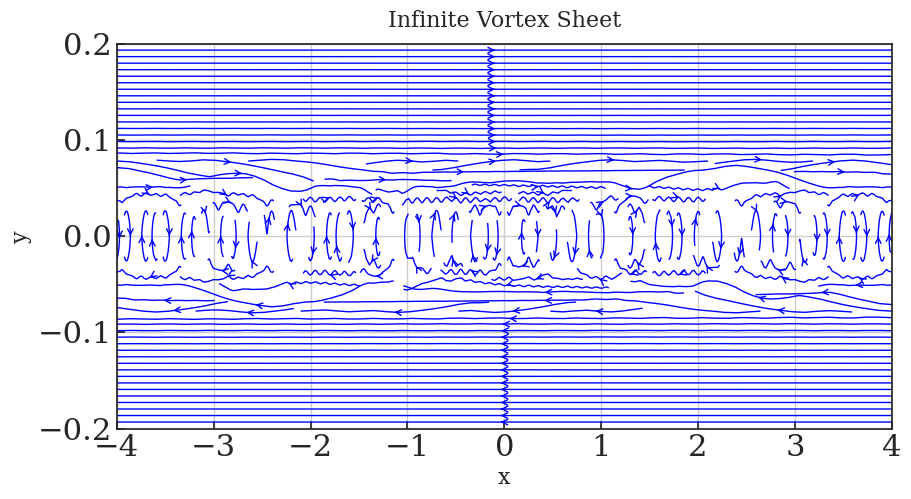

In [195]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate velocity field for an infinite vortex sheet
def infinite_vortex_vel(Gamma, a, X, Y):

    u = (Gamma / (2 * a)) * (np.sinh((2 * np.pi * Y) / a) /
                             (np.cosh((2 * np.pi * Y) / a) - np.cos((2 * np.pi * X) / a)))
    v = -(Gamma / (2 * a)) * (np.sin((2 * np.pi * X) / a) /
                              (np.cosh((2 * np.pi * Y) / a) - np.cos((2 * np.pi * X) / a)))
    return u, v

# Parameters for the vortex sheet
a = 0.1       # Small spacing between vortices
x_start, x_end = -4, 4  # X range for the plot
y_start, y_end = -0.2, 0.2  # Y range for the plot
x_points, y_points = 500, 200  # Higher resolution for better visualization

# Create the meshgrid
x = np.linspace(x_start, x_end, x_points)
y = np.linspace(y_start, y_end, y_points)
X, Y = np.meshgrid(x, y)

# Calculate the velocity field
u, v = infinite_vortex_vel(Gamma, a, X, Y)

# Plotting the velocity field
plt.figure(figsize=(10, 5))
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)
plt.title('Infinite Vortex Sheet', fontsize=16)
plt.grid(True)

# Streamlines for velocity field
plt.streamplot(X, Y, u, v, density=2, linewidth=1, arrowsize=1, arrowstyle='->', color='blue')
plt.show()


2.0 Setting up the Vortex Panel Method

[ 0.00189     0.00314702  0.00688713  0.01296517  0.02085257  0.02990854
  0.04030336  0.05074604  0.0610968   0.07083739  0.07941     0.0853858
  0.08867435  0.08953869  0.08643377  0.07947359  0.06893434  0.05506114
  0.03876316  0.01399097  0.          0.01399097 -0.03876316 -0.05506114
 -0.06893434 -0.07947359 -0.08643377 -0.08953869 -0.08867435 -0.0853858
 -0.07941    -0.07083739 -0.0610968  -0.05074604 -0.04030336 -0.02990854
 -0.02085257 -0.01296517 -0.00688713 -0.00314702  0.00189   ]
[ 0.00126     0.00225421  0.00519139  0.00987138  0.01606129  0.02337102
  0.03152427  0.04003647  0.04863631  0.05673756  0.0640616   0.06989392
  0.0740607   0.07576995  0.0751775   0.07115105  0.0632429   0.05059782
  0.03534402  0.02008277  0.         -0.00841125 -0.01684645 -0.02327287
 -0.02881956 -0.03463138 -0.04023814 -0.04368042 -0.04509268 -0.04424
 -0.04182498 -0.03793451 -0.03320329 -0.02782479 -0.02229421 -0.016799
 -0.01176478 -0.00741458 -0.00408535 -0.00197125  0.00126   ]
0.67022

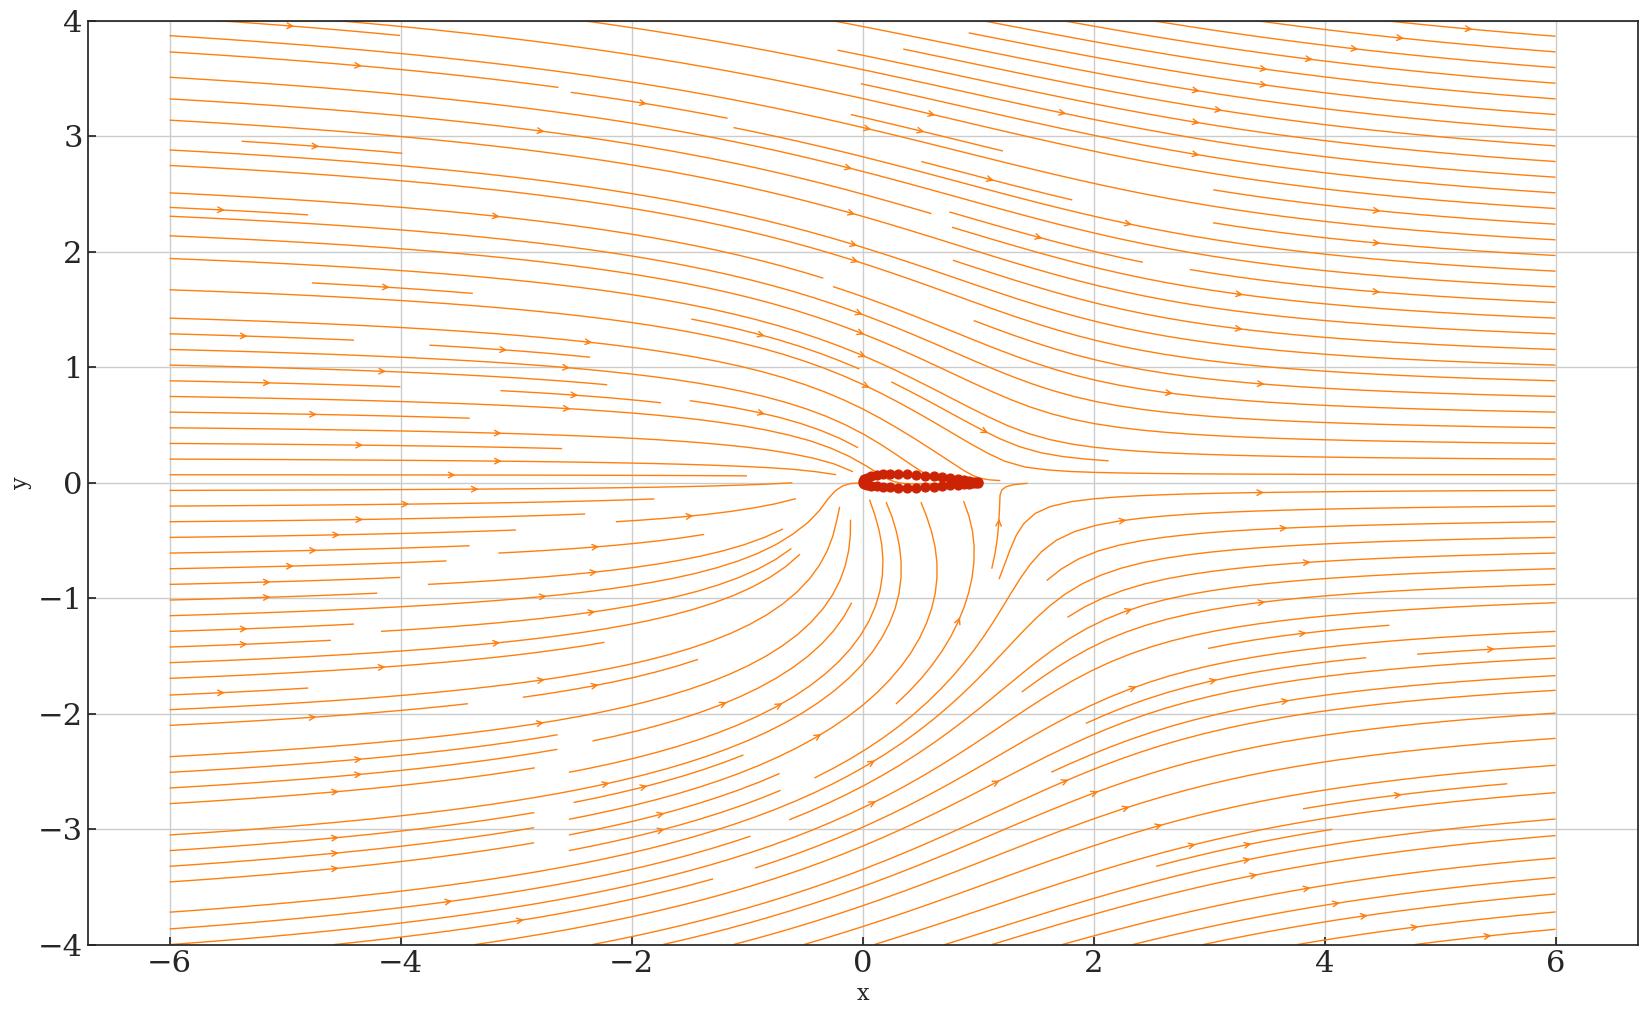

[ 0.00189     0.00314702  0.00688713  0.01296517  0.02085257  0.02990854
  0.04030336  0.05074604  0.0610968   0.07083739  0.07941     0.0853858
  0.08867435  0.08953869  0.08643377  0.07947359  0.06893434  0.05506114
  0.03876316  0.01399097  0.          0.01399097 -0.03876316 -0.05506114
 -0.06893434 -0.07947359 -0.08643377 -0.08953869 -0.08867435 -0.0853858
 -0.07941    -0.07083739 -0.0610968  -0.05074604 -0.04030336 -0.02990854
 -0.02085257 -0.01296517 -0.00688713 -0.00314702  0.00189   ]
[ 0.00126     0.00225421  0.00519139  0.00987138  0.01606129  0.02337102
  0.03152427  0.04003647  0.04863631  0.05673756  0.0640616   0.06989392
  0.0740607   0.07576995  0.0751775   0.07115105  0.0632429   0.05059782
  0.03534402  0.02008277  0.         -0.00841125 -0.01684645 -0.02327287
 -0.02881956 -0.03463138 -0.04023814 -0.04368042 -0.04509268 -0.04424
 -0.04182498 -0.03793451 -0.03320329 -0.02782479 -0.02229421 -0.016799
 -0.01176478 -0.00741458 -0.00408535 -0.00197125  0.00126   ]
3.44876

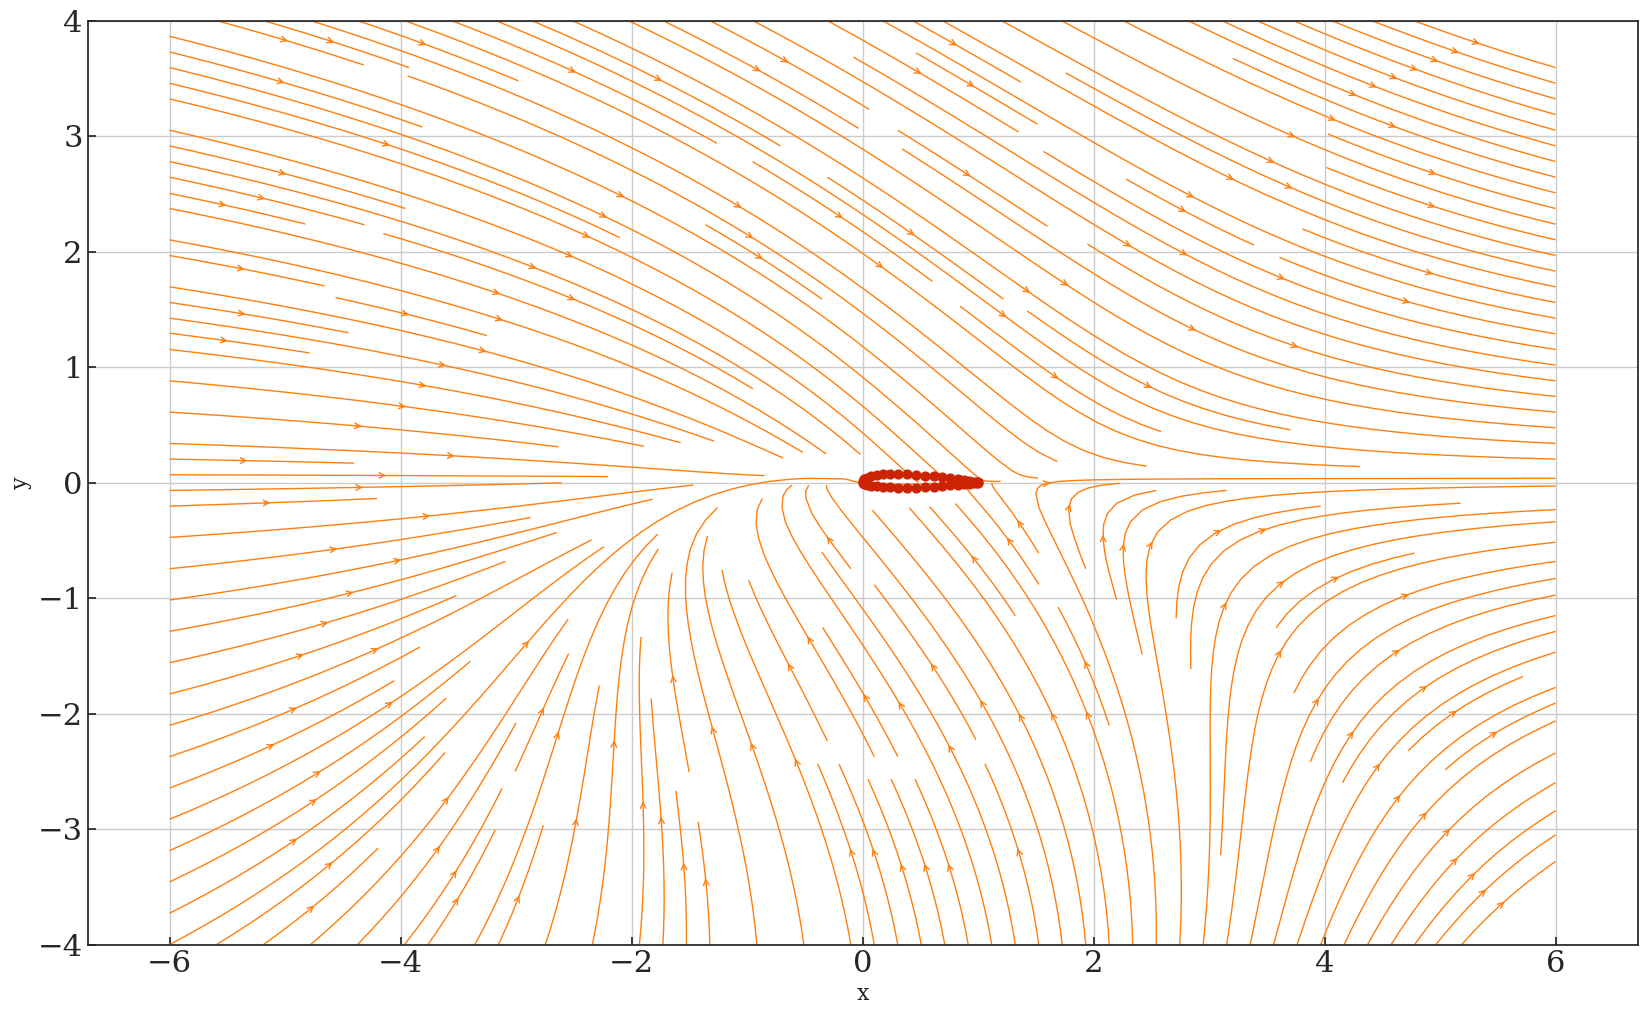

[ 0.00189     0.00314702  0.00688713  0.01296517  0.02085257  0.02990854
  0.04030336  0.05074604  0.0610968   0.07083739  0.07941     0.0853858
  0.08867435  0.08953869  0.08643377  0.07947359  0.06893434  0.05506114
  0.03876316  0.01399097  0.          0.01399097 -0.03876316 -0.05506114
 -0.06893434 -0.07947359 -0.08643377 -0.08953869 -0.08867435 -0.0853858
 -0.07941    -0.07083739 -0.0610968  -0.05074604 -0.04030336 -0.02990854
 -0.02085257 -0.01296517 -0.00688713 -0.00314702  0.00189   ]
[ 0.00126     0.00225421  0.00519139  0.00987138  0.01606129  0.02337102
  0.03152427  0.04003647  0.04863631  0.05673756  0.0640616   0.06989392
  0.0740607   0.07576995  0.0751775   0.07115105  0.0632429   0.05059782
  0.03534402  0.02008277  0.         -0.00841125 -0.01684645 -0.02327287
 -0.02881956 -0.03463138 -0.04023814 -0.04368042 -0.04509268 -0.04424
 -0.04182498 -0.03793451 -0.03320329 -0.02782479 -0.02229421 -0.016799
 -0.01176478 -0.00741458 -0.00408535 -0.00197125  0.00126   ]
0.32590

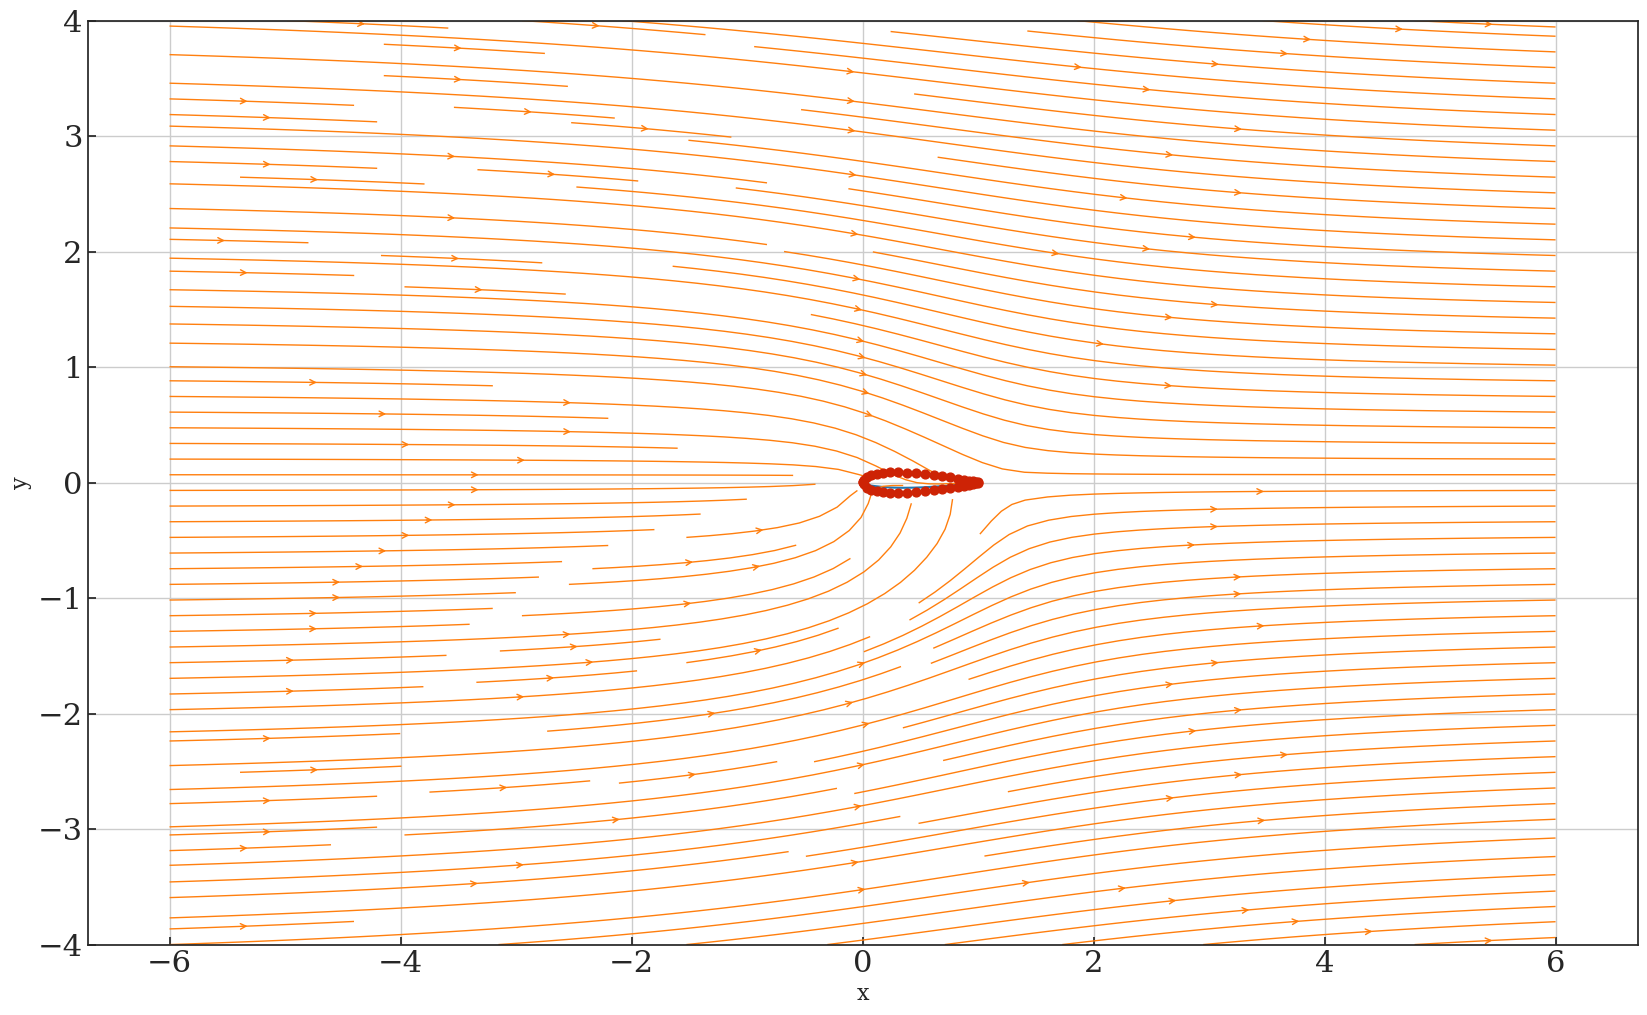

[ 0.00189     0.00314702  0.00688713  0.01296517  0.02085257  0.02990854
  0.04030336  0.05074604  0.0610968   0.07083739  0.07941     0.0853858
  0.08867435  0.08953869  0.08643377  0.07947359  0.06893434  0.05506114
  0.03876316  0.01399097  0.          0.01399097 -0.03876316 -0.05506114
 -0.06893434 -0.07947359 -0.08643377 -0.08953869 -0.08867435 -0.0853858
 -0.07941    -0.07083739 -0.0610968  -0.05074604 -0.04030336 -0.02990854
 -0.02085257 -0.01296517 -0.00688713 -0.00314702  0.00189   ]
[ 0.00126     0.00225421  0.00519139  0.00987138  0.01606129  0.02337102
  0.03152427  0.04003647  0.04863631  0.05673756  0.0640616   0.06989392
  0.0740607   0.07576995  0.0751775   0.07115105  0.0632429   0.05059782
  0.03534402  0.02008277  0.         -0.00841125 -0.01684645 -0.02327287
 -0.02881956 -0.03463138 -0.04023814 -0.04368042 -0.04509268 -0.04424
 -0.04182498 -0.03793451 -0.03320329 -0.02782479 -0.02229421 -0.016799
 -0.01176478 -0.00741458 -0.00408535 -0.00197125  0.00126   ]
2.48690

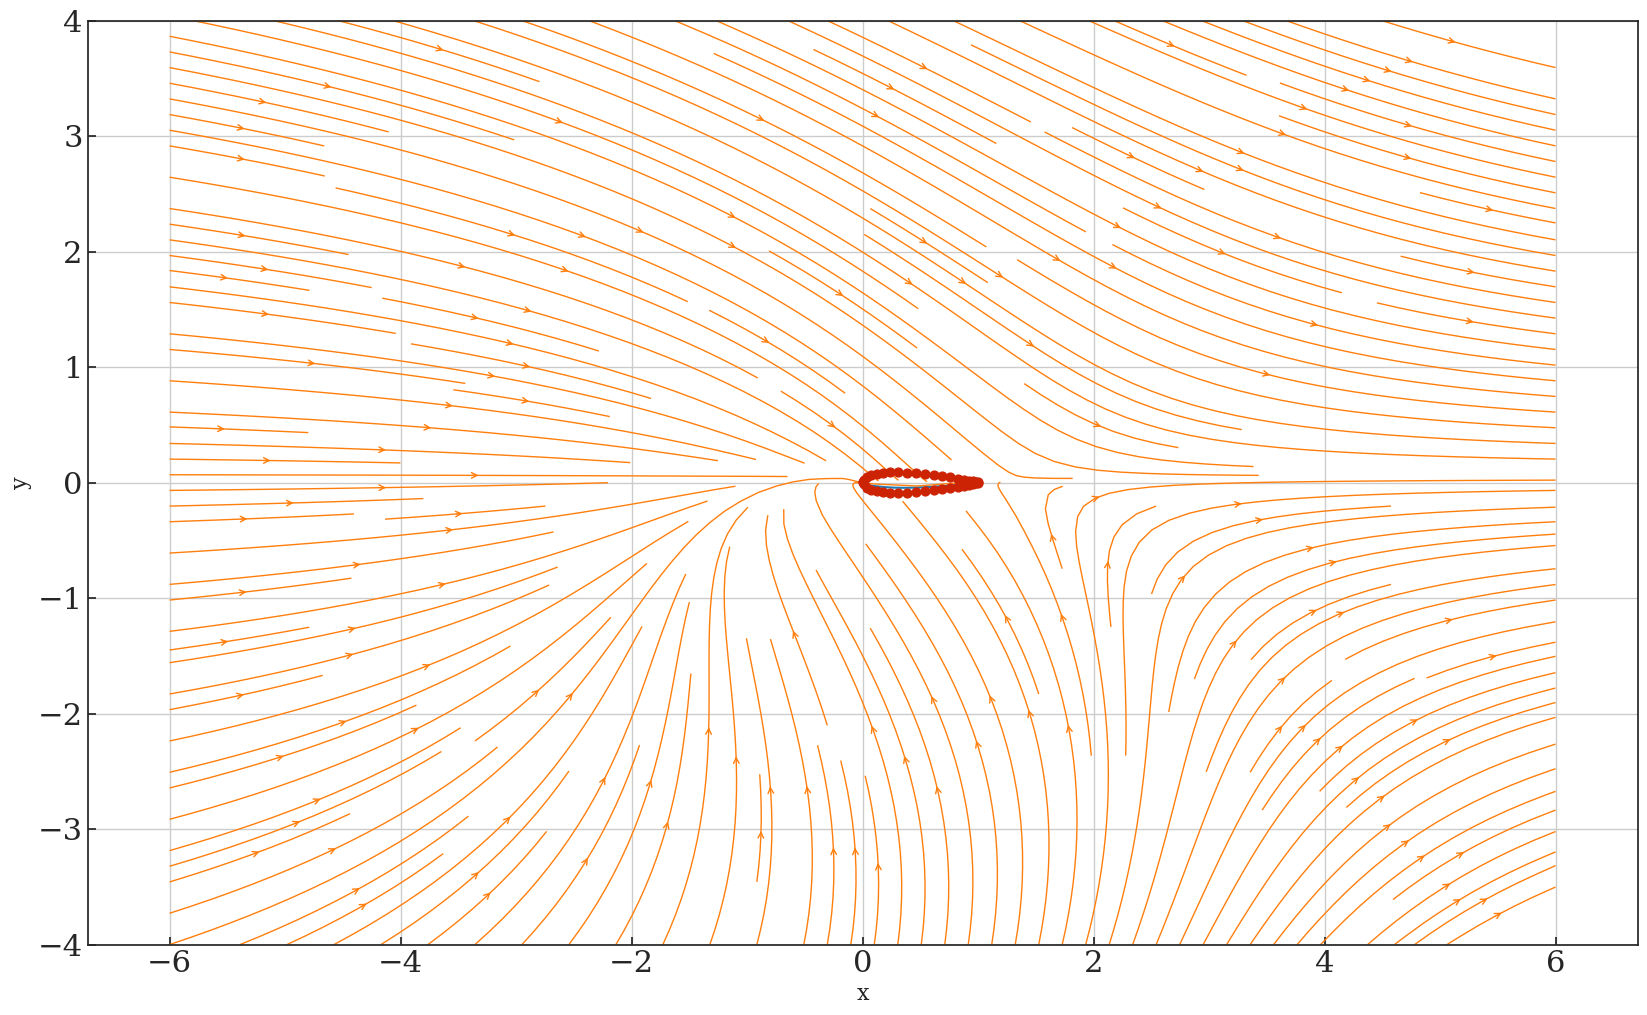

0.3259099226326476
sum of singularity strengths: 0.047208
2.4869098223707136
sum of singularity strengths: 0.232164
0.6702240997449616
sum of singularity strengths: 0.015257
3.448767949909621
sum of singularity strengths: 0.033769


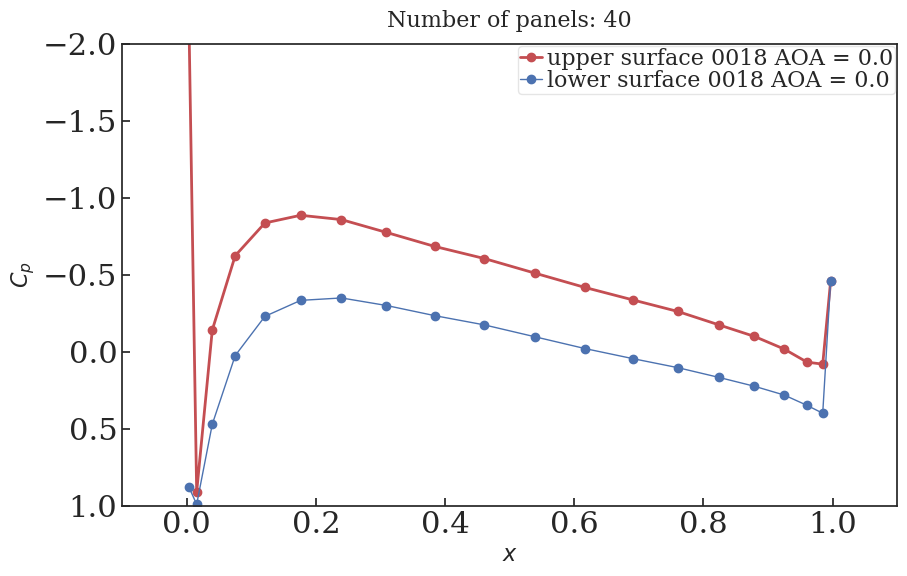

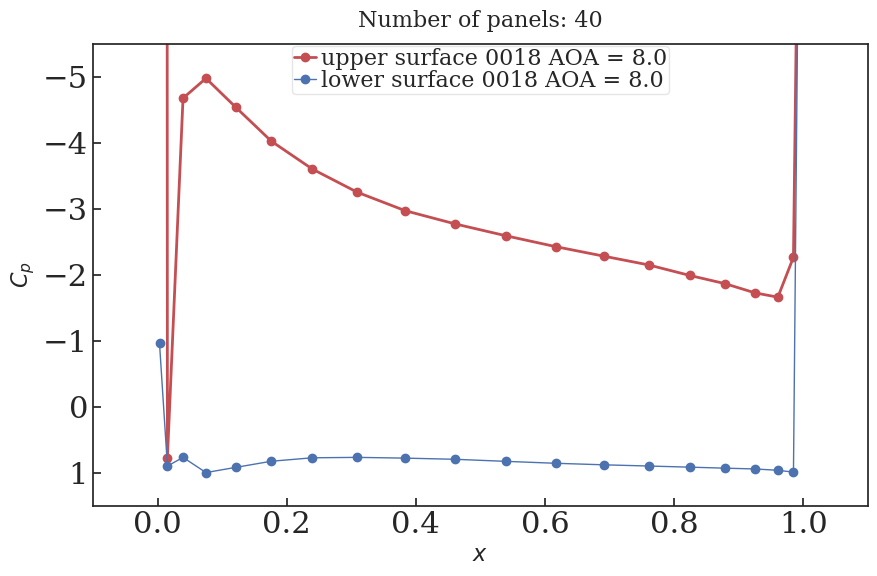

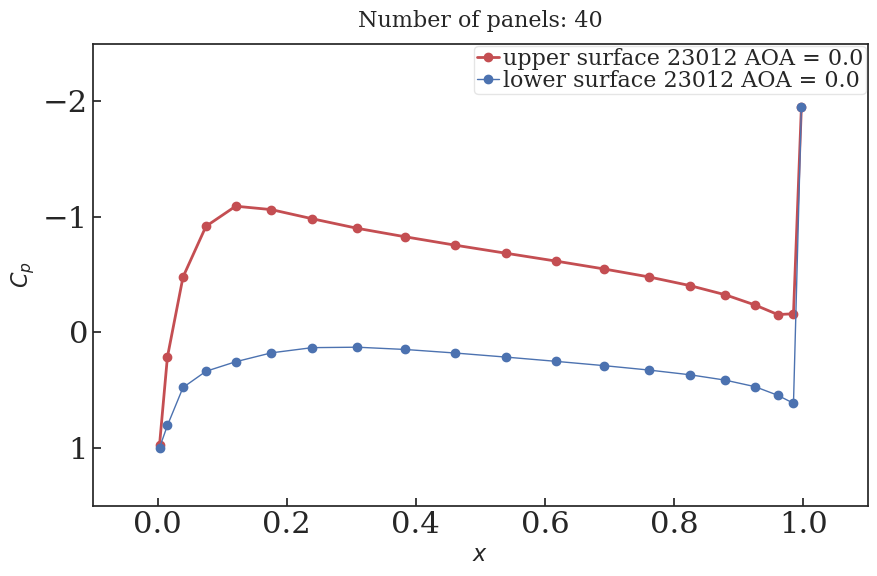

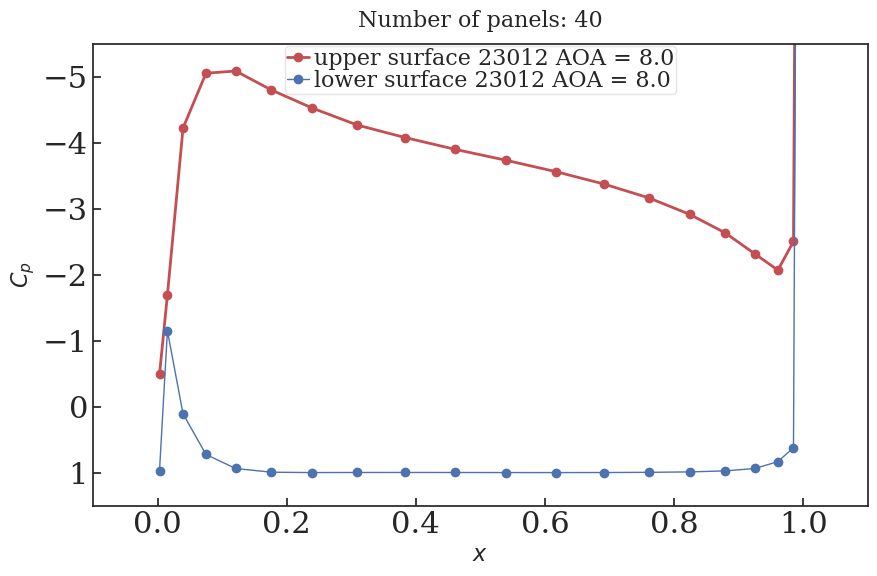

In [203]:
class Panel:
   
    def __init__(self, xa, ya, xb, yb):
      

        self.xa, self.ya = xa, ya           # Defines the first end point
        self.xb, self.yb = xb, yb           # Defines the second end point

        # Defining center point and panel parameters
        # You will need to define these yourself:
        self.xc, self.yc = (xa + xb) / 2, (ya + yb) / 2         # Control point or center point 
        self.length = np.sqrt((xb - xa)**2 + (yb - ya)**2)  # panel length 

        # For the orientation of the panel (angle between x axis and the unit vector normal to the panel)
        if xb - xa <= 0:
            self.beta = np.arccos((yb - ya) / self.length)
        elif xb - xa > 0:
            self.beta = np.pi + np.arccos(-(yb - ya) / self.length)

        # Location of the panel (we will use this later when we expand our analys to airfoils)
        if self.beta <= math.pi:
            self.loc = 'upper'
        else:
            self.loc = 'lower'

        # We also need 3 more parameters, sigma, vt for tangential velocity, and cp for pressure distribution. 
        # Create these and set the equal to zero for now

        self.sigma = 0.0 
        self.vt = 0.0
        self.cp = 0.0



def define_panels(x, y, N=40):
    
    R = (x.max() - x.min()) / 2  # radius of the circle
    x_center = (x.max() + x.min()) / 2  # x-coord of the center
    # define x-coord of the circle points
    x_circle = x_center + R * np.cos(np.linspace(0.0, 2 * math.pi, N + 1))
    
    x_ends = np.copy(x_circle)  # projection of the x-coord on the surface
    y_ends = np.empty_like(x_ends)  # initialization of the y-coord Numpy array

    x = np.append(x, x[0])
    y = np.append(y, y[0])


    test = len(x_ends)
    for i in range(0, test-1):
        if (x_ends[i] < min(x)):
            x_ends[i] = min(x)

 
    # computes the y-coordinate of end-points
    I = 0
    for i in range(N):
        while I < len(x) - 1:
            if (x[I] <= x_ends[i] <= x[I + 1]) or (x[I + 1] <= x_ends[i] <= x[I]):
                break
            else:
                I += 1
        # Interpoaltion Process (Finding Y Points)   
        a = (y[I + 1] - y[I]) / (x[I + 1] - x[I])
        b = y[I + 1] - a * x[I + 1]
        y_ends[i] = a * x_ends[i] + b
        

    y_ends[N] = y_ends[0]
    print(y_ends)
    
    panels = np.empty(N, dtype=object)
    for i in range(N):
        panels[i] = Panel(x_ends[i], y_ends[i], x_ends[i + 1], y_ends[i + 1])
    
    return panels




def integral_normal(p_i, p_j):

    def integrand(s):
        return (((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s)) * math.cos(p_i.beta) +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s)) * math.sin(p_i.beta)) /
                ((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s))**2 +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s))**2))
    return integrate.quad(integrand, 0.0, p_j.length)[0]



def source_integral_normal(p_i, p_j):

    ## Fill in the equation below for the function integrand
    def integrand(s):
        return (((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s)) * math.cos(p_i.beta) +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s)) * math.sin(p_i.beta)) /
                ((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s))**2 +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s))**2))
    return integrate.quad(integrand, 0.0, p_j.length)[0]




def vortex_integral_normal(p_i, p_j):

    # STUDENTS COMPLETE THE CODE BELOW:
    def integrand(s):
        return (((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s)) * math.sin(p_i.beta) +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s)) * math.cos(p_i.beta)) /
                ((p_i.xc - (p_j.xa - math.sin(p_j.beta) * s))**2 +
                 (p_i.yc - (p_j.ya + math.cos(p_j.beta) * s))**2))
    return integrate.quad(integrand, 0.0, p_j.length)[0]



class Freestream:
   
    def __init__(self, u_inf=2.2, alpha=0.0):
      
        self.u_inf = u_inf
        self.alpha = np.radians(alpha)  # degrees to radians
# define freestream conditions
freestream = Freestream(u_inf=2.2, alpha=0.0)



def analyze_panels(panels, uinf, alpha):

    N = len(panels)

    A_s = np.empty((N, N), dtype = float)
    A_v = np.empty((N, N), dtype = float)

    np.fill_diagonal(A_s, 0.5)
        # Whenever we have i = j, we have sigma(i)/2 or sigma(i)*0.5. Thus, on our diagonal for matrix A we should have 0.5 
        # The diagonal of a matrix means i = j i.e (1,1), (2,2), etc etc.
        # Remember that this represents how much a source panel conributes to its OWN normal velocity

    np.fill_diagonal(A_v, 0.0)
        # Here, we have the same thing, but for vortex contributions on normal velocity.

    # Create the source influence matrix [A_s] of the linear system
    # This represents how much a source panel contributes to OTHER panels normal velocity.
    for i, p_i in enumerate(panels):
        for j, p_j in enumerate(panels):
            if i != j:
                A_s[i,j] = (0.5/math.pi) * source_integral_normal(p_i, p_j)
                # Here, we create a matrix called A_s to hold the source contributions
                # Make sure that you change this to use our new functions rather than our old ones. 

    # Create the vortex influence matrix [A_v]
    for i, p_i in enumerate(panels):
        for j, p_j in enumerate(panels):
            if i != j:
                A_v[i,j] = -(0.5/math.pi) * vortex_integral_normal(p_i, p_j)
                # Here, we create a matrix called A_s to hold the source contributions
                # Make sure that you change this to use our new functions rather than our old ones. 

    A_s_norm = A_s
    A_v_norm = A_v

    # Kutta Condition:
    # First, lets create an array to hold all of our values.
    # This array should be of length N + 1 (the number of panels + 1)
    Kutta = np.empty(A_s.shape[0] + 1, dtype=float)
    
    # Next, we would like all the elements of our Kutta array (except the last)
    # to be equal to the first and last values of our vortex contribution matrix.
    Kutta[:-1] = A_v[0, :] + A_v[-1, :]

    # Finally, we make the last element of our Kutta array equal to the sum of 
    # all the last elements of our source contribution matrix. 
    Kutta[-1] = - np.sum(A_s[0, :] + A_s[-1, :])


    A = np.empty((N+1, N+1), dtype = float)

    # Enter the source contribution matrix
    # This takes up all but the last column and all but the last row
    # The vortex strength (gamma) and the kutta condition will take this place 
    A[:-1, :-1] = A_s_norm

    # Enter the vortex contribution array
    # Fills in the last column
    A[:-1, -1] = np.sum(A_v_norm, axis = 1)

    # Enter the Kutta array
    # Fills in the last row
    A[-1, :] = Kutta

    # Freestream Velocity and Matrix b
    # Lets start by creating an empty array b
    alpha = np.radians(alpha)
    b = np.empty(N + 1, dtype = float)

    for i, panel in enumerate(panels):
        b[i] = - uinf * math.cos(alpha - panel.beta)

    # Freestream contribution on the Kutta condition
    b[-1] = - uinf * (math.sin(alpha - panels[0].beta) + math.sin(alpha - panels[-1].beta))

    # Here we solve for the Strength sigma
    Strengths = np.linalg.solve(A, b)

    for i, panel in enumerate(panels):
        panel.sigma = Strengths[i]

    # The very last value in our strength array is the value gamma, or the constant vortex strength across each panel

    gamma = Strengths[-1]
    print(gamma)

    
    # Now tht we know what our source panel strengths are, as well as our vortex strength, we can use these values
    # In order to computer the tangential velocity at each panel. We use a new array in order to do this
    
    # Computing Tangential Velocity
    A_t = np.empty((panels.size, panels.size+1), dtype = float)

    A_t[:, :-1] = A_v
    A_t[:, -1] = -np.sum(A_s, axis = 1)
    
    b_t = uinf * np.sin([alpha - panel.beta for panel in panels])

    vortex_strengths = np.append([panel.sigma for panel in panels], gamma)

    tan_vel = np.dot(A_t, vortex_strengths) + b_t

    for i, panel in enumerate(panels):
        panel.vt = tan_vel[i]


    # Finally, we need to compute the pressure coefficient. 
    for panel in panels:
        panel.cp = 1.0 - (panel.vt / freestream.u_inf)**2

    accuracy = sum([panel.sigma * panel.length for panel in panels])
    print('sum of singularity strengths: {:0.6f}'.format(accuracy))





def get_vortex_sum(Gamma,xv,yv,X,Y):
    sumU = np.zeros(len(X))
    sumV = np.zeros(len(Y))
    
    for i in range(len(xv)):
        x = X - xv[i]
        y = Y - yv[i]

        sumU = sumU + (Gamma/(2*np.pi))*(y/((x**2)+(y**2)))
        sumV = sumV + (-(Gamma/(2*np.pi)))*(y/((x**2)+(y**2)))
    return sumU, sumV

def FS(u_inf):
    u_freestream = u_inf * np.ones((N,N), dtype=float)
    v_freestream = np.zeros((N,N), dtype=float)

    return u_freestream, v_freestream





filename = "../naca0018.txt"
x12, z12 = np.loadtxt(filename, unpack = True, skiprows = 1)

filename = "../naca23012.txt"
x23, z23 = np.loadtxt(filename, unpack = True, skiprows = 1)




N = 40
x_start, x_end = -6.0, 6.0
y_start, y_end = -4.0, 4.0
x = np.linspace(x_start, x_end, N)
y = np.linspace(y_start, y_end, N)
X, Y = np.meshgrid(x, y)
Gamma = 5

panels12 = define_panels(x12, z12, 40)

panels23 = define_panels(x23, z23, 40)

analyze_panels(panels23, 2.2, 0.0)

u_freestream = 2.2 * np.ones((N,N), dtype=float)
v_freestream = np.zeros((N,N), dtype=float)


u_vort_up, v_vort_up = get_vortex_sum(0.67022409974496, [panel.xc for panel in panels23 if panel.loc == 'upper'], [panel.yc for panel in panels23 if panel.loc == 'upper'],X,Y)
u_vort_lo, v_vort_lo = get_vortex_sum(-0.67022409974496, [panel.xc for panel in panels23 if panel.loc == 'upper'], [panel.yc for panel in panels23 if panel.loc == 'upper'],X,Y)
Utotal= u_freestream + u_vort_up
Vtotal = v_freestream + v_vort_up
# Here, we define some panels using the x and y points and the number of panels we would like to use. 

# Lets plot these panels on the above plot. 
#plt.streamplot(X, Y, u_vort_lo, v_vort_lo, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.figure(figsize = (20,12))
plt.grid(True)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
#plt.xlim(x_start, x_end)
#plt.ylim(y_start, y_end)
plt.plot(x23, z23)
plt.streamplot(X, Y, Utotal, Vtotal, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.scatter([p.xc for p in panels23], [p.yc for p in panels23],
               label='source-panel method',
               color='#CD2305', s=40, zorder=2)
plt.axis('equal')
plt.show()







N = 40
x_start, x_end = -6.0, 6.0
y_start, y_end = -4.0, 4.0
x = np.linspace(x_start, x_end, N)
y = np.linspace(y_start, y_end, N)
X, Y = np.meshgrid(x, y)
Gamma = 5

panels12 = define_panels(x12, z12, 40)

panels23 = define_panels(x23, z23, 40)

analyze_panels(panels23, 2.2, 8.0)

u_freestream = 2.2 * np.ones((N,N), dtype=float)
v_freestream = np.zeros((N,N), dtype=float)


u_vort_up, v_vort_up = get_vortex_sum(3.448767949909629, [panel.xc for panel in panels23 if panel.loc == 'upper'], [panel.yc for panel in panels23 if panel.loc == 'upper'],X,Y)
u_vort_lo, v_vort_lo = get_vortex_sum(-3.448767949909629, [panel.xc for panel in panels23 if panel.loc == 'upper'], [panel.yc for panel in panels23 if panel.loc == 'upper'],X,Y)
Utotal= u_freestream + u_vort_up
Vtotal = v_freestream + v_vort_up
# Here, we define some panels using the x and y points and the number of panels we would like to use. 

# Lets plot these panels on the above plot. 
#plt.streamplot(X, Y, u_vort_lo, v_vort_lo, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.figure(figsize = (20,12))
plt.grid(True)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
#plt.xlim(x_start, x_end)
#plt.ylim(y_start, y_end)
plt.plot(x23, z23)
plt.streamplot(X, Y, Utotal, Vtotal, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.scatter([p.xc for p in panels23], [p.yc for p in panels23],
               label='source-panel method',
               color='#CD2305', s=40, zorder=2)
plt.axis('equal')
plt.show()





N = 40
x_start, x_end = -6.0, 6.0
y_start, y_end = -4.0, 4.0
x = np.linspace(x_start, x_end, N)
y = np.linspace(y_start, y_end, N)
X, Y = np.meshgrid(x, y)
Gamma = 5

panels12 = define_panels(x12, z12, 40)

panels23 = define_panels(x23, z23, 40)

analyze_panels(panels12, 2.2, 0.0)

u_freestream = 2.2 * np.ones((N,N), dtype=float)
v_freestream = np.zeros((N,N), dtype=float)


u_vort_up, v_vort_up = get_vortex_sum(0.3259099226326479, [panel.xc for panel in panels12 if panel.loc == 'upper'], [panel.yc for panel in panels12 if panel.loc == 'upper'],X,Y)
u_vort_lo, v_vort_lo = get_vortex_sum(-0.3259099226326479, [panel.xc for panel in panels12 if panel.loc == 'upper'], [panel.yc for panel in panels12 if panel.loc == 'upper'],X,Y)
Utotal= u_freestream + u_vort_up
Vtotal = v_freestream + v_vort_up
# Here, we define some panels using the x and y points and the number of panels we would like to use. 

# Lets plot these panels on the above plot. 
#plt.streamplot(X, Y, u_vort_lo, v_vort_lo, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.figure(figsize = (20,12))
plt.grid(True)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
#plt.xlim(x_start, x_end)
#plt.ylim(y_start, y_end)
plt.plot(x23, z23)
plt.streamplot(X, Y, Utotal, Vtotal, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.scatter([p.xc for p in panels12], [p.yc for p in panels12],
               label='source-panel method',
               color='#CD2305', s=40, zorder=2)
plt.axis('equal')
plt.show()




N = 40
x_start, x_end = -6.0, 6.0
y_start, y_end = -4.0, 4.0
x = np.linspace(x_start, x_end, N)
y = np.linspace(y_start, y_end, N)
X, Y = np.meshgrid(x, y)
Gamma = 5

panels12 = define_panels(x12, z12, 40)

panels23 = define_panels(x23, z23, 40)

analyze_panels(panels12, 2.2, 8.0)

u_freestream = 2.2 * np.ones((N,N), dtype=float)
v_freestream = np.zeros((N,N), dtype=float)


u_vort_up, v_vort_up = get_vortex_sum(2.4869098223707153, [panel.xc for panel in panels12 if panel.loc == 'upper'], [panel.yc for panel in panels12 if panel.loc == 'upper'],X,Y)
u_vort_lo, v_vort_lo = get_vortex_sum(-2.4869098223707153, [panel.xc for panel in panels12 if panel.loc == 'upper'], [panel.yc for panel in panels12 if panel.loc == 'upper'],X,Y)
Utotal= u_freestream + u_vort_up
Vtotal = v_freestream + v_vort_up
# Here, we define some panels using the x and y points and the number of panels we would like to use. 

# Lets plot these panels on the above plot. 
#plt.streamplot(X, Y, u_vort_lo, v_vort_lo, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.figure(figsize = (20,12))
plt.grid(True)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
#plt.xlim(x_start, x_end)
#plt.ylim(y_start, y_end)
plt.plot(x23, z23)
plt.streamplot(X, Y, Utotal, Vtotal, density=2, linewidth=1, arrowsize=1, arrowstyle='->')
plt.scatter([p.xc for p in panels12], [p.yc for p in panels12],
               label='source-panel method',
               color='#CD2305', s=40, zorder=2)
plt.axis('equal')
plt.show()



analyze_panels(panels12, 2.2, 0.0)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot([panel.xc for panel in panels12 if panel.loc == 'upper'],
            [panel.cp for panel in panels12 if panel.loc == 'upper'],
            label='upper surface 0018 AOA = 0.0',
            color='r', linestyle='-', linewidth=2, marker='o', markersize=6)
plt.plot([panel.xc for panel in panels12 if panel.loc == 'lower'],
            [panel.cp for panel in panels12 if panel.loc == 'lower'],
            label= 'lower surface 0018 AOA = 0.0',
            color='b', linestyle='-', linewidth=1, marker='o', markersize=6)
plt.legend(loc='best', prop={'size':16})
plt.xlim(-0.1, 1.1)
plt.ylim(1.0, -2.0)
plt.title('Number of panels: {}'.format(panels12.size), fontsize=16)


analyze_panels(panels12, 2.2, 8.0)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot([panel.xc for panel in panels12 if panel.loc == 'upper'],
            [panel.cp for panel in panels12 if panel.loc == 'upper'],
            label='upper surface 0018 AOA = 8.0',
            color='r', linestyle='-', linewidth=2, marker='o', markersize=6)
plt.plot([panel.xc for panel in panels12 if panel.loc == 'lower'],
            [panel.cp for panel in panels12 if panel.loc == 'lower'],
            label= 'lower surface 0018 AOA = 8.0',
            color='b', linestyle='-', linewidth=1, marker='o', markersize=6)
plt.legend(loc='best', prop={'size':16})
plt.xlim(-0.1, 1.1)
plt.ylim(1.5, -5.5)
plt.title('Number of panels: {}'.format(panels12.size), fontsize=16);




analyze_panels(panels23, 2.2, 0.0)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot([panel.xc for panel in panels23 if panel.loc == 'upper'],
            [panel.cp for panel in panels23 if panel.loc == 'upper'],
            label='upper surface 23012 AOA = 0.0',
            color='r', linestyle='-', linewidth=2, marker='o', markersize=6)
plt.plot([panel.xc for panel in panels23 if panel.loc == 'lower'],
            [panel.cp for panel in panels23 if panel.loc == 'lower'],
            label= 'lower surface 23012 AOA = 0.0',
            color='b', linestyle='-', linewidth=1, marker='o', markersize=6)
plt.legend(loc='best', prop={'size':16})
plt.xlim(-0.1, 1.1)
plt.ylim(1.5, -2.5)
plt.title('Number of panels: {}'.format(panels23.size), fontsize=16);




analyze_panels(panels23, 2.2, 8.0)

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$C_p$', fontsize=16)
plt.plot([panel.xc for panel in panels23 if panel.loc == 'upper'],
            [panel.cp for panel in panels23 if panel.loc == 'upper'],
            label='upper surface 23012 AOA = 8.0',
            color='r', linestyle='-', linewidth=2, marker='o', markersize=6)
plt.plot([panel.xc for panel in panels23 if panel.loc == 'lower'],
            [panel.cp for panel in panels23 if panel.loc == 'lower'],
            label= 'lower surface 23012 AOA = 8.0',
            color='b', linestyle='-', linewidth=1, marker='o', markersize=6)
plt.legend(loc='best', prop={'size':16})
plt.xlim(-0.1, 1.1)
plt.ylim(1.5, -5.5)
plt.title('Number of panels: {}'.format(panels23.size), fontsize=16);

A vortex panel method calculates lift for a cambered airfoil because vortexes include circulation, which satisfyies the Kutta condition. In contrast, a source panel method models the surface with sources and sinks, which can simulate flow but cannot generate circulation or lift. Computationally, the vortex panel method requires solving for vortex strengths, typically leading to a more complex system of equations than the source panel method, which only computes source strengths.

3.0 Additional Problems

3.1 Airfoil Performance

In [197]:
#2412
#4412
#23012
c=7 #ft
alpha=5 #degrees
altitude=5000 #ft
Rec1=2E6
Rec2=9E6


import numpy as np

# Constants
rho = 0.002048  # Air density at 5000 ft in slug/ft^3
mu = 3.737e-7   # Dynamic viscosity in slug/ft-s
chord = 7.0     # Chord length in ft
S = chord * 1.0 # 2D area (span = 1 ft)

# Reynolds numbers
Re_values = [3e6, 9e6]

# Airfoil coefficients
coefficients = {
    "NACA 2412": {"Cl": 0.75, "Cd": 0.0095},
    "NACA 4412": {"Cl": 1.00, "Cd": 0.0100},
    "NACA 23012": {"Cl": 0.70, "Cd": 0.0085}
}

# Function to calculate velocity, dynamic pressure, lift, and drag
def calculate_forces(Re, Cl, Cd):
    # Calculate velocity
    V = Re * mu / (rho * chord)
    # Calculate dynamic pressure
    q = 0.5 * rho * V**2
    # Calculate lift and drag forces
    L = Cl * q * S
    D = Cd * q * S
    return V, q, L, D

# Iterate over airfoils and Reynolds numbers
for airfoil, coeffs in coefficients.items():
    print(f"\nAirfoil: {airfoil}")
    Cl, Cd = coeffs["Cl"], coeffs["Cd"]
    for Re in Re_values:
        V, q, L, D = calculate_forces(Re, Cl, Cd)
        print(f"  Reynolds number: {Re:.1e}")
        print(f"    Velocity: {V:.2f} ft/s")
        print(f"    Dynamic Pressure: {q:.2f} lb/ft^2")
        print(f"    Lift: {L:.2f} lb")
        print(f"    Drag: {D:.2f} lb")






Airfoil: NACA 2412
  Reynolds number: 3.0e+06
    Velocity: 78.20 ft/s
    Dynamic Pressure: 6.26 lb/ft^2
    Lift: 32.88 lb
    Drag: 0.42 lb
  Reynolds number: 9.0e+06
    Velocity: 234.61 ft/s
    Dynamic Pressure: 56.36 lb/ft^2
    Lift: 295.89 lb
    Drag: 3.75 lb

Airfoil: NACA 4412
  Reynolds number: 3.0e+06
    Velocity: 78.20 ft/s
    Dynamic Pressure: 6.26 lb/ft^2
    Lift: 43.84 lb
    Drag: 0.44 lb
  Reynolds number: 9.0e+06
    Velocity: 234.61 ft/s
    Dynamic Pressure: 56.36 lb/ft^2
    Lift: 394.52 lb
    Drag: 3.95 lb

Airfoil: NACA 23012
  Reynolds number: 3.0e+06
    Velocity: 78.20 ft/s
    Dynamic Pressure: 6.26 lb/ft^2
    Lift: 30.69 lb
    Drag: 0.37 lb
  Reynolds number: 9.0e+06
    Velocity: 234.61 ft/s
    Dynamic Pressure: 56.36 lb/ft^2
    Lift: 276.17 lb
    Drag: 3.35 lb


3.2 Airfoil Efficiency

In [204]:
import sys
import pyxfoil
#Intputs
foil = "23012"
naca = True
Re = 9E6
alfs = [0,1,2,3,4,5,6,7,8,9,10]
pyxfoil.GetPolar(foil, naca, alfs, Re, SaveCP=True)

maxL_D = 155.619

print('The max valuse for L/D for the 23012 airfoil is estimated to be: {:0.6f}'.format(maxL_D))


#Intputs
foil = "2412"
naca = True
Re = 9E6
alfs = [0,1,2,3,4,5,6,7,8,9,10]
pyxfoil.GetPolar(foil, naca, alfs, Re, SaveCP=True)

maxL_D = 135.3174603

print('The max valuse for L/D for the 2412 aifoil is estimated to be: {:0.6f}'.format(maxL_D))


#Intputs
foil = "4412"
naca = True
Re = 9E6
alfs = [0,1,2,3,4,5,6,7,8,9,10]
pyxfoil.GetPolar(foil, naca, alfs, Re, SaveCP=True)

maxL_D = 170.5592105

print('The max valuse for L/D for the 4412 airfoil is estimated to be: {:0.6f}'.format(maxL_D))



The max valuse for L/D for the 23012 airfoil is estimated to be: 155.619000
The max valuse for L/D for the 2412 aifoil is estimated to be: 135.317460
The max valuse for L/D for the 4412 airfoil is estimated to be: 170.559211
